In [1]:
import pickle as pkl

In [2]:
with open("./data/norm_vendors_list_to_idx_map.pkl", "rb") as f:
    data = pkl.load(
        f,
    )

    vendors_idx_to_name = data["idx_to_norm_name"]
    vendors_name_to_idx = data["norm_name_to_idx"]

del data

In [3]:
with open("./data/norm_vendors_csr_matrix.pkl", "rb") as f:
    csr_matrix = pkl.load(f)

In [4]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

In [5]:
svd = TruncatedSVD(n_components=20, n_iter=7, random_state=42)

In [6]:
decomposed = svd.fit_transform(csr_matrix)

In [7]:
embedded = TSNE(
    n_components=2, learning_rate="auto", init="random", random_state=42
).fit_transform(decomposed)

In [18]:
%matplotlib widget
import matplotlib
from matplotlib import pyplot as plt

matplotlib.use("nbagg")

In [19]:
embedded.shape

(35821, 2)

In [20]:
import numpy as np

In [32]:
sample_size = 1000
sample_idxs = np.random.choice(len(embedded), sample_size)

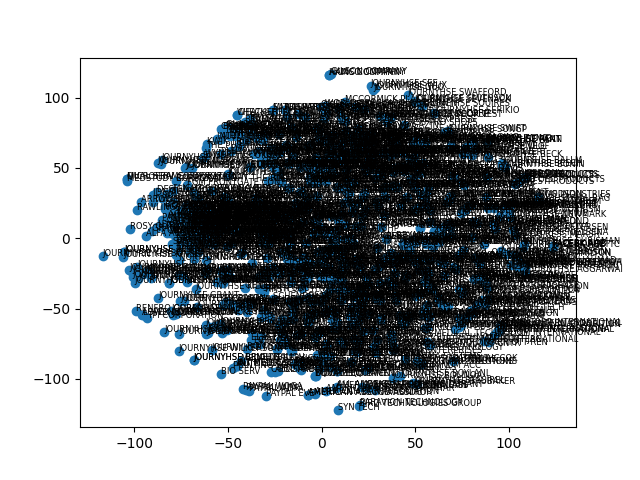

In [33]:
%matplotlib widget
x = embedded[:, 0][sample_idxs]
y = embedded[:, 1][sample_idxs]
tags = np.array(list(vendors_name_to_idx))[sample_idxs]

fig, ax = plt.subplots()
ax.scatter(x, y)

for i, txt in enumerate(tags):
    ax.annotate(txt, (x[i], y[i]), size=6)

plt.show()